In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("students_data.csv")
df.head()


,Student_Name,Age,Gender,Course,Attendance,Assignment_Score,Midterm_Score,Final_Score
0,Alice,24,Female,AI/ML,85.0,90.0,80.0,85.0
1,Bob,22,Male,Data Science,62.0,55.0,60.0,58.0
2,Charlie,21,Male,AI/ML,90.0,95.0,88.0,92.0
3,David,23,Male,Web Dev,45.0,50.0,40.0,42.0
4,Emma,26,Female,AI/ML,70.0,NaN,65.0,60.0


In [2]:
# Veri setindeki sütun tiplerini ve eksik (null) değer sayılarını kontrol ediyoruz
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_Name      30 non-null     str    
 1   Age               30 non-null     int64  
 2   Gender            30 non-null     str    
 3   Course            30 non-null     str    
 4   Attendance        30 non-null     float64
 5   Assignment_Score  29 non-null     float64
 6   Midterm_Score     29 non-null     float64
 7   Final_Score       30 non-null     float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.5 KB


In [3]:
print("Before removing empty values:")
print(df.isnull().sum()) # 1. Hangi sütunda kaç tane boş (NaN) veri var kontrol ediyoruz

# 2. Ödev ve Vize notlarındaki boş değerleri sütun ortalaması (mean) ile dolduruyormuşuz
df['Assignment_Score'] = df['Assignment_Score'].fillna(df['Assignment_Score'].mean())
df['Midterm_Score'] = df['Midterm_Score'].fillna(df['Midterm_Score'].mean())

# 3. Temizlendikten sonra boş değer kalıp kalmadığını teyit ediyormuşuz
print("After removing empty values:")
print(df.isnull().sum())



Before removing empty values:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    1
Midterm_Score       1
Final_Score         0
dtype: int64
After removing empty values:
Student_Name        0
Age                 0
Gender              0
Course              0
Attendance          0
Assignment_Score    0
Midterm_Score       0
Final_Score         0
dtype: int64


In [4]:
# 1. Her öğrenci için Ödev, Vize ve Final notlarının ortalamasını alıp yeni bir sütun oluşturuyoruz
df['Overall_Score'] = (df['Assignment_Score'] + df['Midterm_Score'] + df['Final_Score']) / 3

# 2. Ödevde İstenen: Ortalama notları hesaplama
print("ALL STUDENTS AVERAGE SCORE:")
print(f"Average homework grade: {df['Assignment_Score'].mean():.2f}")
print(f"Average midterm grade: {df['Midterm_Score'].mean():.2f}")
print(f"Average final grade: {df['Final_Score'].mean():.2f}")
print(f"Average overall grade: {df['Overall_Score'].mean():.2f}")

# 3. Ödevde İstenen: En Yüksek ve En Düşük Notları Bulma
print("\n" + "-" * 50)
print("HIGHEST AND LOWEST SCORES:")

# idxmax() genel puanı en yüksek satırı, idxmin() en düşük satırı verirmiş
top_student = df.loc[df['Overall_Score'].idxmax()]
lowest_student = df.loc[df['Overall_Score'].idxmin()]

print(f"highest student: {top_student['Student_Name']} ({top_student['Course']}) - Score: {top_student['Overall_Score']:.2f}")
print(f"lowest student: {lowest_student['Student_Name']} ({lowest_student['Course']}) - Score: {lowest_student['Overall_Score']:.2f}")


ALL STUDENTS AVERAGE SCORE:
Average homework grade: 74.21
Average midterm grade: 72.41
Average final grade: 74.37
Average overall grade: 73.66

--------------------------------------------------
HIGHEST AND LOWEST SCORES:
highest student: Rachel (AI/ML) - Score: 96.33
lowest student: Peter (Cyber Security) - Score: 39.33


In [5]:
# 1. Ödevde İstenen: Devam oranı %75'in altında olan öğrenciler
print("STUDENTS WITH AN ATTENDANCE RATE BELOW 75 PERCENT:")
low_attendance = df[df['Attendance'] < 75]
print(low_attendance[['Student_Name', 'Course', 'Attendance']])

# 2. Ödevde İstenen: Kalma riski olan öğrenciler (Genel puanı 50'nin altında veya devamı 75'in altında olanlar)
print("\n" + "-" * 50)
print("STUDENTS AT RISK OF FAILING:")
at_risk_students = df[(df['Overall_Score'] < 50) | (df['Attendance'] < 75)]  # '|' işareti VEYA anlamına gelrmiş (Devam < 75 veya Genel Puan < 50)
print(at_risk_students[['Student_Name', 'Course', 'Overall_Score', 'Attendance']])

# 3. Ödevde İstenen: Kurs bazında ortalama notlar
# groupby('Course') veriyi kurslara göre gruplar ve her kursun kendi ortalamasını alır
print("\n" + "-" * 50)
print("AVERAGE SCORES BY COURSE:")
course_averages = df.groupby('Course') ['Overall_Score'].mean()
print(course_averages)

STUDENTS WITH AN ATTENDANCE RATE BELOW 75 PERCENT:
   Student_Name          Course  Attendance
1           Bob    Data Science        62.0
3         David         Web Dev        45.0
4          Emma           AI/ML        70.0
6         Grace  Cyber Security        68.0
7        Hannah           AI/ML        74.0
9          Jack    Data Science        59.0
11         Liam         Web Dev        50.0
15        Peter  Cyber Security        40.0
18          Sam    Data Science        60.0
19         Tina         Web Dev        72.0
21       Victor  Cyber Security        55.0
23       Xavier         Web Dev        65.0
25         Zack  Cyber Security        48.0

--------------------------------------------------
STUDENTS AT RISK OF FAILING:
   Student_Name          Course  Overall_Score  Attendance
1           Bob    Data Science      57.666667        62.0
3         David         Web Dev      44.000000        45.0
4          Emma           AI/ML      66.402299        70.0
6         Grace 

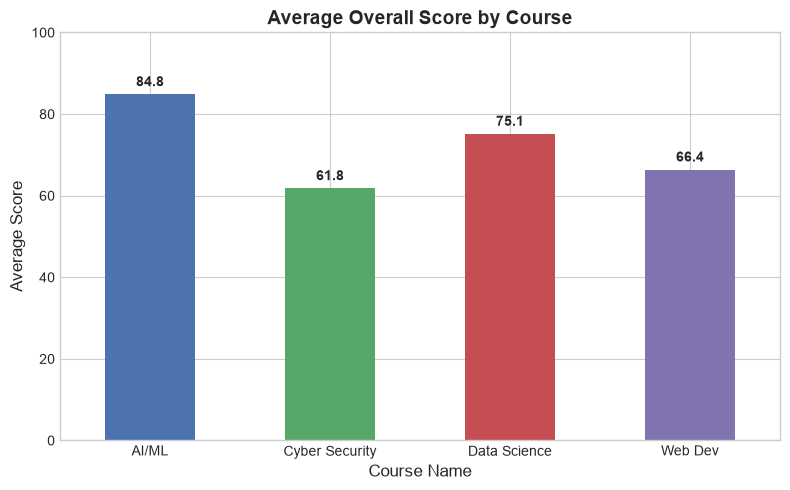

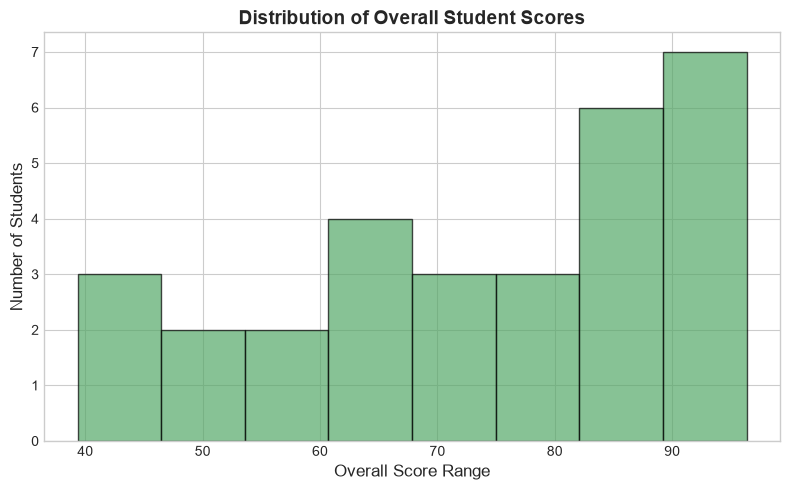

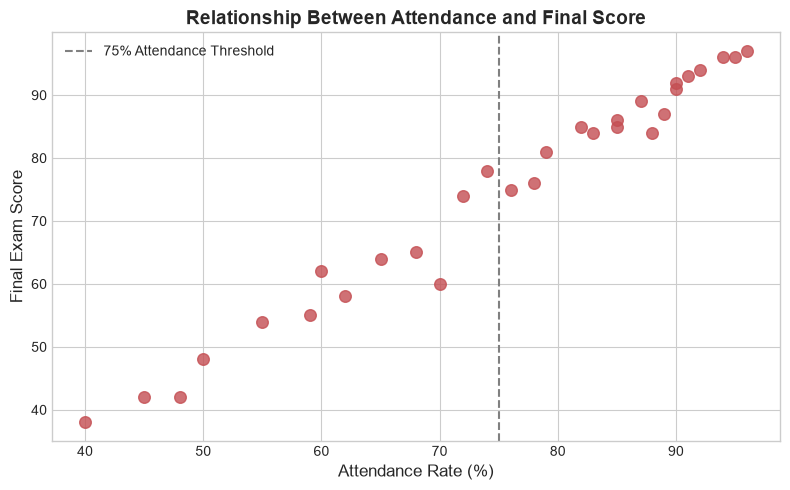

In [6]:
import matplotlib.pyplot as plt

# Grafiklerimizin daha şık görünmesi için stil ayarlıyoruz
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# ---------------------------------------------------------
# GRAFİK 1: Kurs Bazında Ortalama Puanlar (Bar Chart)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
course_averages.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B0'])
plt.title('Average Overall Score by Course', fontsize=14, fontweight='bold')
plt.xlabel('Course Name', fontsize=12)
plt.ylabel('Average Score', fontsize=12)
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Değerleri barların üzerine yazdırıyoruz
for index, value in enumerate(course_averages):
    plt.text(index, value + 2, f"{value:.1f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('chart1_course_averages.png') # Resmi klasöre kaydeder
plt.show() # Grafiği jupyter ekranında gösterir

# ---------------------------------------------------------
# GRAFİK 2: Genel Başarı Not Dağılımı (Histogram)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(df['Overall_Score'], bins=8, color='#55A868', edgecolor='black', alpha=0.7)
plt.title('Distribution of Overall Student Scores', fontsize=14, fontweight='bold')
plt.xlabel('Overall Score Range', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)

plt.tight_layout()
plt.savefig('chart2_score_distribution.png')
plt.show()

# ---------------------------------------------------------
# GRAFİK 3: Devam Oranı ve Final Notu İlişkisi (Scatter Plot)
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(df['Attendance'], df['Final_Score'], color='#C44E52', s=70, alpha=0.8)
plt.title('Relationship Between Attendance and Final Score', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Rate (%)', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)
plt.axvline(x=75, color='gray', linestyle='--', label='75% Attendance Threshold')
plt.legend()

plt.tight_layout()
plt.savefig('chart3_attendance_vs_final.png')
plt.show()